## Setup

In [2]:
import Pkg
Pkg.activate(@__DIR__)
Pkg.status()

  Activating project at `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis`


Status `~/Documents/Carnegie-Mellon/Chatterjee Group/Programming/WignerMolecule.jl/analysis/Project.toml`
  [13f3f980] CairoMakie v0.15.10
⌃ [780c37f4] Carlo v0.2.6
  [074ae576] CarloAnalysis v1.0.0-DEV `https://github.com/PatXue/CarloAnalysis.jl#main`
  [a93c6f00] DataFrames v1.8.2
  [f67ccb44] HDF5 v0.17.3
  [033835bb] JLD2 v0.6.4
  [ebeed567] PeriodicArrays v0.1.0 `https://github.com/PatXue/PeriodicArrays.jl#main`
  [90137ffa] StaticArrays v1.9.18
Info Packages marked with ⌃ have new versions available and may be upgradable.


In [3]:
using CairoMakie
using Carlo.ResultTools
using CarloAnalysis
using DataFrames
using HDF5
using JLD2
using LinearAlgebra
using PeriodicArrays
using StaticArrays

In [4]:
function generate_spins(jobname, task_no)
    fig = Figure(size=(800, 400))

    task_str = lpad(task_no, 4, "0")
    h5open("../jobs/$jobname.data/task$task_str/run0001.dump.h5") do file
        spins = map(
            t -> [t[:data][1], t[:data][2], t[:data][3]],
            read(file, "simulation/spins")
        )
        spin_xs = map(v -> v[1], spins)
        spin_ys = map(v -> v[2], spins)
        spin_zs = map(v -> v[3], spins)
        Lx, Ly = size(spins)
        fig[1,1] = Axis(fig; title="Spins", backgroundcolor="black")
        strength = vec(spin_zs)
        arrows2d!(1:Lx, 1:Ly, spin_xs, spin_ys, lengthscale=0.5, align=:center, color=strength,
                  colorrange=(-1, 1))

        ηs = map(
            t -> [t[:data][1], t[:data][2], t[:data][3]],
            read(file, "simulation/etas")
        )
        η_xs = getindex.(ηs, 1)
        η_ys = getindex.(ηs, 2)
        η_zs = getindex.(ηs, 3)
        Lx, Ly = size(ηs)
        fig[1,2] = Axis(fig; title="ηs", backgroundcolor="black")
        strength = vec(η_zs)
        arrows2d!(1:Lx, 1:Ly, η_xs, η_ys, lengthscale=0.5, align=:center, color=strength,
                  colorrange=(-1, 1))
    end

    return fig
end

generate_spins (generic function with 1 method)

## Zero-field Runs

In [5]:
results = JobResult("../eta-jobs", "fm")

JobResult("../eta-jobs", "fm", 10×29 DataFrame
 Row │ ChiQ             sk_corr_M3                         Q                 s ⋯
     │ Measurem…        Array…                             Measurem…         A ⋯
─────┼──────────────────────────────────────────────────────────────────────────
   1 │ 8.37e-5±2.5e-6   Complex{Measurement{Float64}}[8.…  -0.000239±1.2e-5  C ⋯
   2 │ 0.001633±2.7e-5  Complex{Measurement{Float64}}[0.…  -0.000985±3.5e-5  C
   3 │ 0.01033±0.00019  Complex{Measurement{Float64}}[0.…   0.002239±5.4e-5  C
   4 │ 0.04929±0.00077  Complex{Measurement{Float64}}[0.…   0.00435±0.00014  C
   5 │ 0.2226±0.0063    Complex{Measurement{Float64}}[0.…  -0.00423±0.00023  C ⋯
   6 │ 0.3796±0.0054    Complex{Measurement{Float64}}[0.…  -0.00014±0.0003   C
   7 │ 0.4098±0.0051    Complex{Measurement{Float64}}[0.…   0.00016±0.00039  C
   8 │ 0.424±0.0051     Complex{Measurement{Float64}}[0.…  -0.00024±0.00028  C
   9 │ 0.4294±0.0035    Complex{Measurement{Float64}}[0.…  -0.00029±0.0001

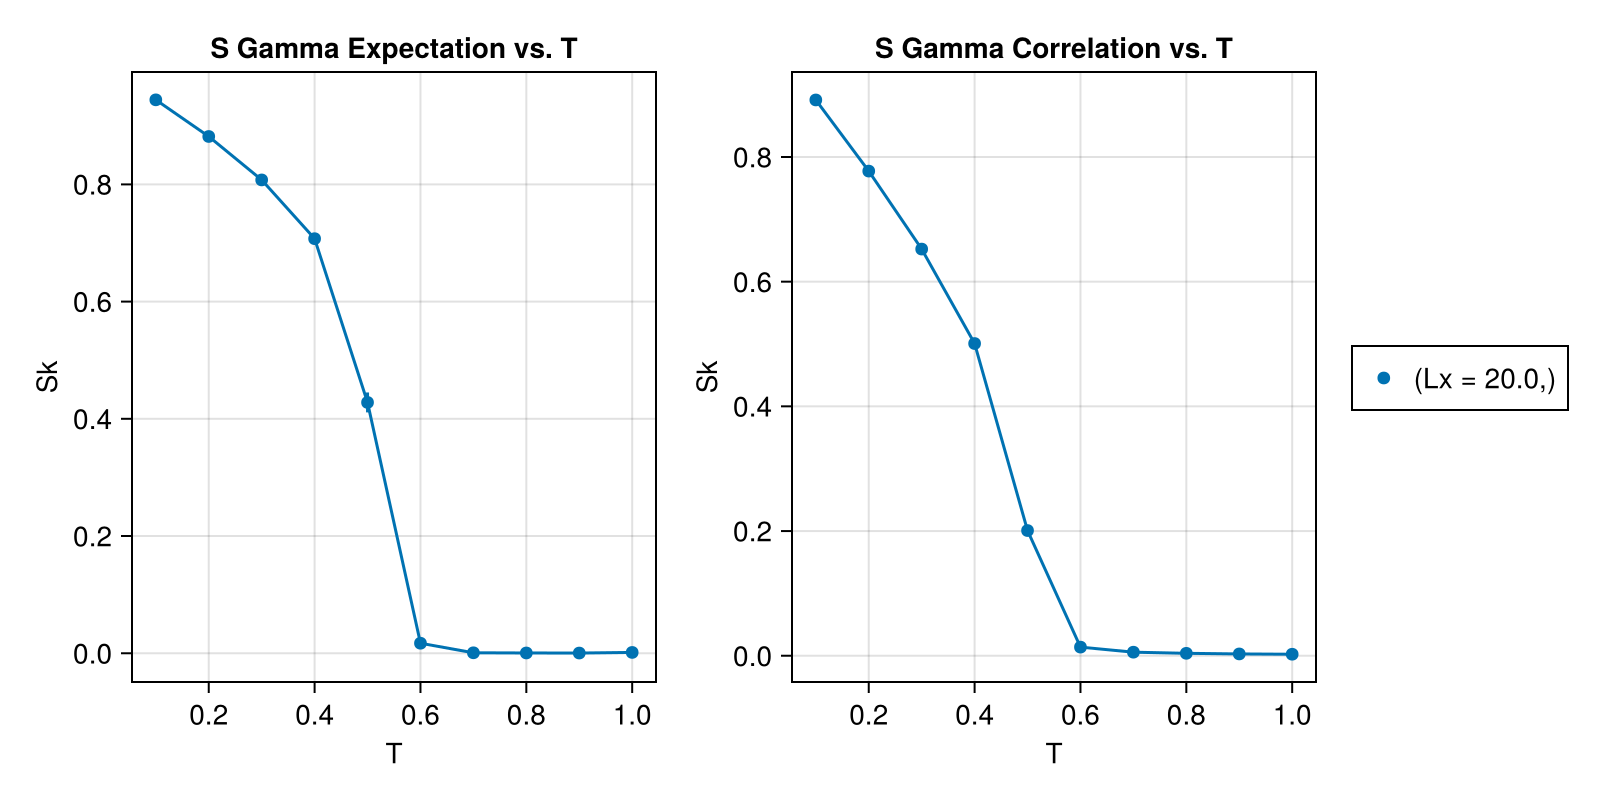

In [8]:
fig = Figure(size=(800, 400))

fig[1,1] = ax_e = Axis(fig, title="S Gamma Expectation vs. T", xlabel="T", ylabel="Sk")
generate_plot!(ax_e, :T, :sk_Γ, [:Lx], results.data; line=true) do sk
    abs.(getindex.(sk, 3))
end
fig[1,2] = ax_η = Axis(fig, title="S Gamma Correlation vs. T", xlabel="T", ylabel="Sk")
generate_plot!(ax_η, :T, :sk_corr_Γ, [:Lx], results.data; line=true) do sk
    real.(getindex.(sk, 3, 3))
end
Legend(fig[1,3], ax_η)
fig

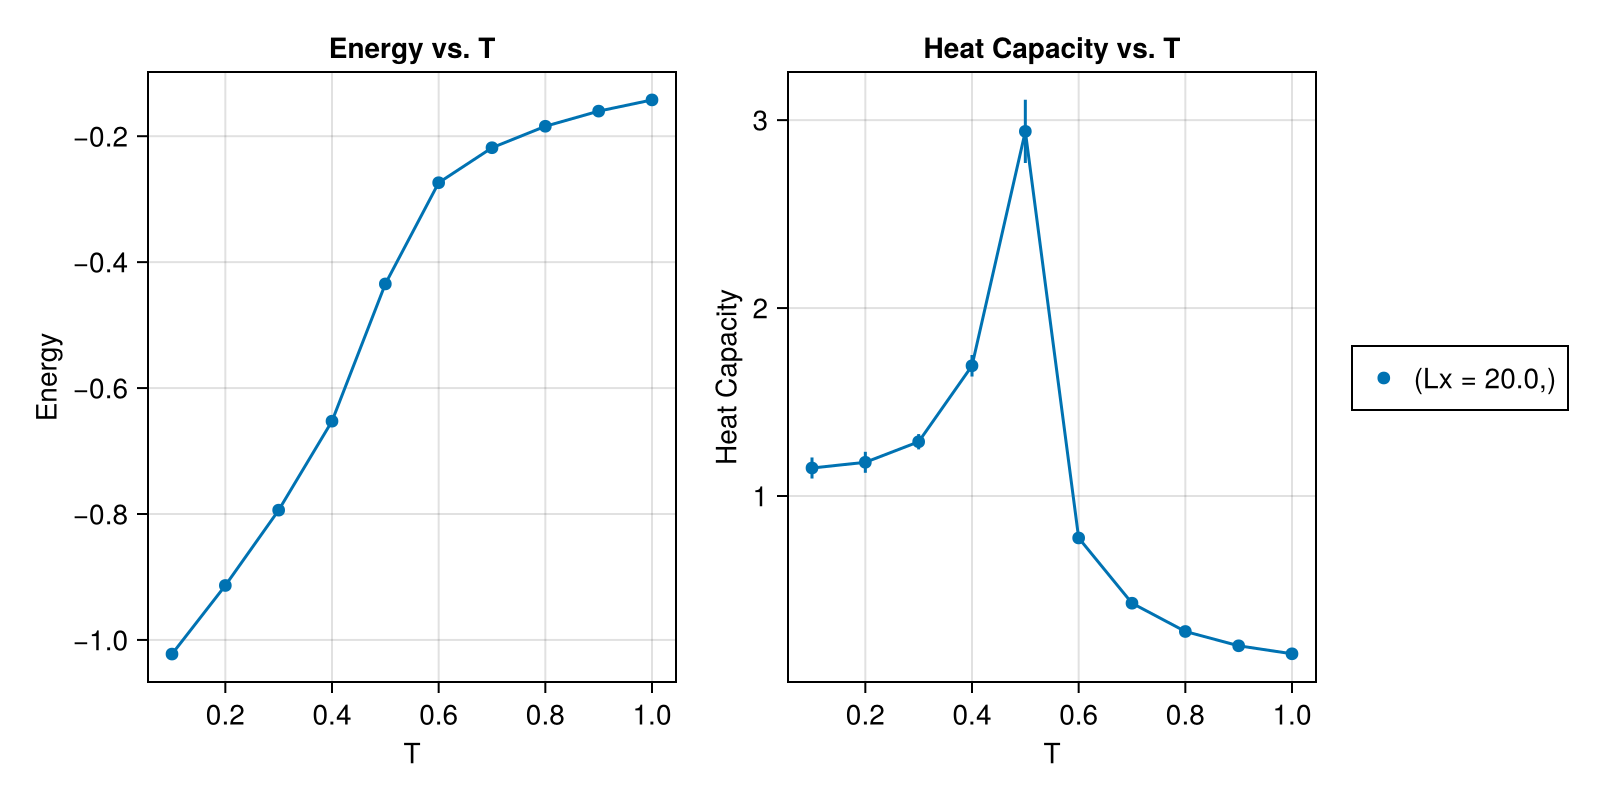

In [9]:
fig = Figure(size=(800, 400))

fig[1,1] = ax_e = Axis(fig, title="Energy vs. T", xlabel="T", ylabel="Energy")
generate_plot!(ax_e, :T, :Energy, [:Lx], results.data; line=true)
fig[1,2] = ax_η = Axis(fig, title="Heat Capacity vs. T", xlabel="T", ylabel="Heat Capacity")
generate_plot!(ax_η, :T, :HeatCap, [:Lx], results.data; line=true)
Legend(fig[1,3], ax_η)
fig

In [10]:
mctimes = get_mctime_data(results, :sk_corr_Γ, :sk_Γ)
nothing

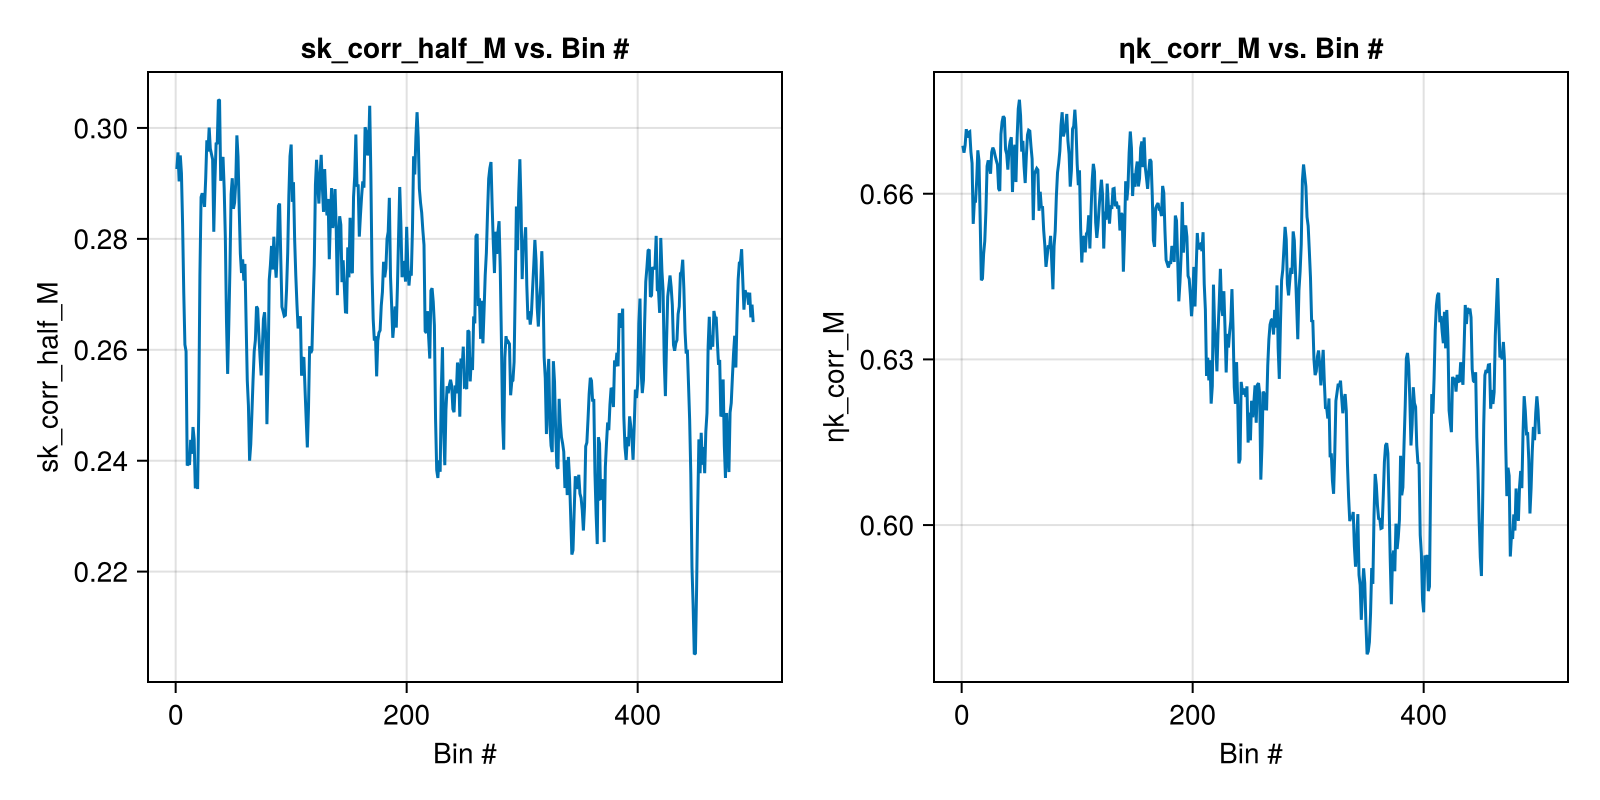

In [ ]:
CairoMakie.activate!()
i = 38
k_pos = (1, 11)

var1 = :sk_corr_half_M
data1 = first.(mctimes[i][:, var1])
var2 = :ηk_corr_M
data2 = mctimes[i][:, var2]
fig = Figure(size=(800, 400))
fig[1,1] = ax1 = Axis(fig, title="$var1 vs. Bin #", xlabel="Bin #", ylabel="$var1")
fig[1,2] = ax2 = Axis(fig, title="$var2 vs. Bin #", xlabel="Bin #", ylabel="$var2")
lines!(ax1, real.(data1))
lines!(ax2, [real(ηk[1,1] + ηk[2,2]) for ηk in data2])
fig